# 02 — Análise estatística: Selic × crédito

**Pergunta:** quando o Copom muda a Selic, o saldo de financiamentos muda junto — e com quanto atraso? Por modalidade e por estado.

Este notebook **não recalcula nada**: ele lê o que o pipeline (`scripts/run_pipeline.py`) gravou em `data/final/` e as figuras em `docs/figuras/`, e explica como ler cada resultado. As regras estão na seção 5.4 do `docs/architecture.md`.

**Como a medida funciona, em uma frase:** para cada mês, comparamos *quanto o saldo de crédito variou* com *quanto a Selic meta variou k meses antes* (k de 0 a 6). A **correlação de Spearman** diz se os dois costumam andar juntos (+1), em sentidos opostos (−1) ou sem relação (0).

> ⚠️ Tudo aqui é **associação, não causa**. Uma correlação positiva não quer dizer que a Selic *faz* o crédito crescer.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Permite importar `src` com o notebook rodando de dentro de notebooks/.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import config
from src.analise.correlacao import nome_curto

gold = pd.read_parquet(config.ARQUIVO_GOLD)
brasil = pd.read_parquet(config.ARQUIVO_ANALISE_BRASIL)
uf = pd.read_parquet(config.ARQUIVO_ANALISE_UF)
relatorio_gold = pd.read_json(config.ARQUIVO_RELATORIO_GOLD, typ="series")

print(f"Gold: {len(gold):,} linhas (mês × UF × modalidade), {gold['ano_mes'].nunique()} meses "
      f"({gold['ano_mes'].min()} a {gold['ano_mes'].max()})")
print(f"Órfãos: SCR sem Selic = {relatorio_gold['orfaos_meses_scr_sem_selic'] or 'nenhum'}; "
      f"Selic sem SCR = {relatorio_gold['orfaos_meses_selic_sem_scr'] or 'nenhum'}")
print(f"Linhas sem mês anterior (variação vazia): {relatorio_gold['linhas_sem_mes_anterior']:,}")

Gold: 24,578 linhas (mês × UF × modalidade), 120 meses (2016-07-01 a 2026-06-01)
Órfãos: SCR sem Selic = nenhum; Selic sem SCR = nenhum
Linhas sem mês anterior (variação vazia): 393


## 1. A Selic que usamos

A Selic é a **meta fixada pelo Copom**, em % ao ano, no **último dia de cada mês**. A variação mensal (`var_selic_pp`) é, portanto, a decisão do Copom naquele mês: 0 quando não mudou, −0,25 quando cortou 0,25 ponto etc.

*(Até a Sprint 4 o projeto usava a Selic acumulada no mês, em % ao mês. Ela foi trocada porque varia com o número de dias úteis — em mar/2026 ela subiu enquanto o Copom cortou. Ver seção 2.2 do `architecture.md`.)*

In [2]:
selic = gold.drop_duplicates("ano_mes").set_index("ano_mes")[["selic_pct", "var_selic_pp"]]
mudancas = selic[selic["var_selic_pp"].fillna(0) != 0]
print(f"A meta mudou em {len(mudancas)} dos {len(selic)} meses do recorte.")
print(f"Mínimo: {selic['selic_pct'].min():.2f}% a.a. | máximo: {selic['selic_pct'].max():.2f}% a.a.")
selic.tail(6)

A meta mudou em 50 dos 120 meses do recorte.
Mínimo: 2.00% a.a. | máximo: 15.00% a.a.


,selic_pct,var_selic_pp
ano_mes,,
2026-01-01,15.00,0.00
2026-02-01,15.00,0.00
2026-03-01,14.75,-0.25
2026-04-01,14.50,-0.25
2026-05-01,14.50,0.00
2026-06-01,14.25,-0.25


## 2. Nível Brasil, por modalidade — o primeiro gráfico

Para cada modalidade, somamos o saldo das 27 UFs em cada mês e medimos a correlação da variação desse saldo com a variação da Selic **k meses antes**.

**Como ler:** cada painel é uma modalidade; cada barra é uma defasagem (0 = mesmo mês, 6 = seis meses antes). Barra para cima (vermelha) = os dois andam juntos; para baixo (azul) = em sentidos opostos. **Cor cheia = significativa** depois do ajuste para muitos testes; cor clara = pode ser acaso.

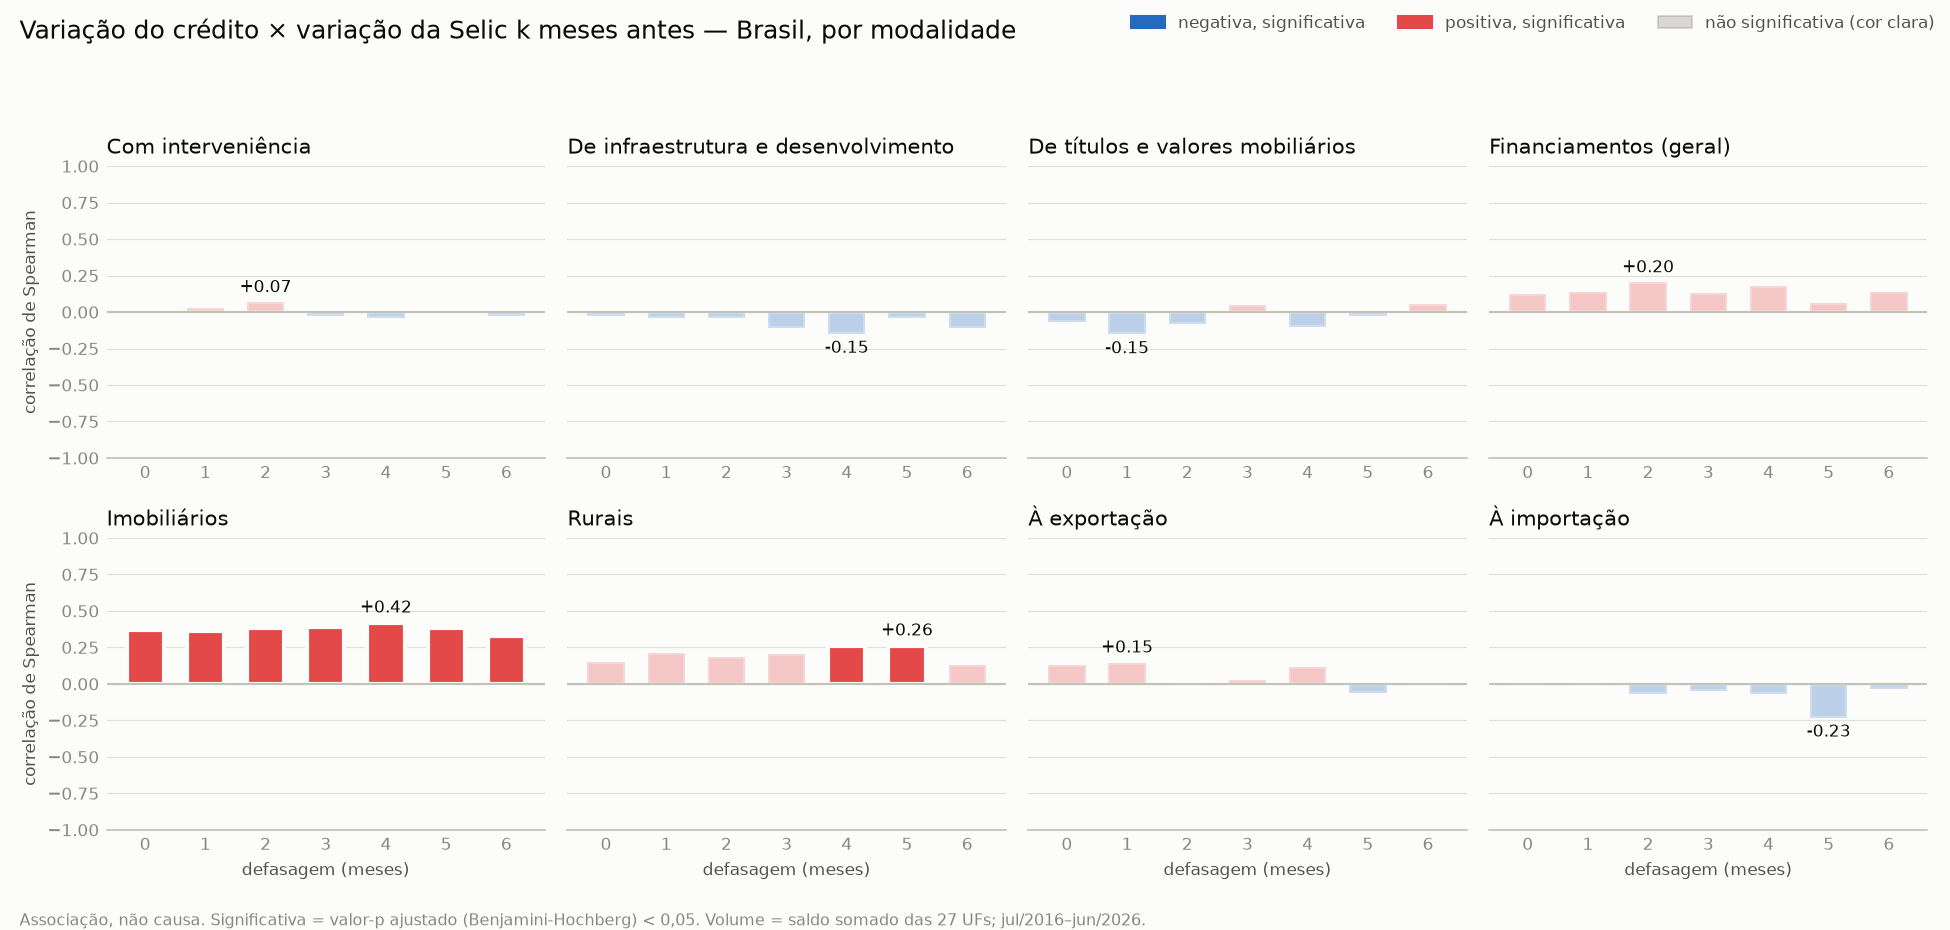

In [3]:
display(Image(filename=str(config.DIR_FIGURAS / "correlacao_por_modalidade.png")))

In [4]:
# Para cada modalidade, a defasagem com a associação mais forte
mais_forte = brasil.loc[brasil["spearman"].abs().groupby(brasil["modalidade"]).idxmax()].copy()
mais_forte["modalidade"] = mais_forte["modalidade"].map(nome_curto)
mais_forte.sort_values("spearman")[["modalidade", "defasagem_meses", "n_meses", "spearman", "pearson",
                                    "p_ajustado", "significativo"]].round(3)

,modalidade,defasagem_meses,n_meses,spearman,pearson,p_ajustado,significativo
54,À importação,5,114,-0.231,-0.041,0.075,False
22,De títulos e valores mobiliários,1,118,-0.152,-0.126,0.328,False
18,De infraestrutura e desenvolvimento,4,115,-0.149,-0.049,0.343,False
9,Com interveniência,2,117,0.067,0.121,0.775,False
43,À exportação,1,118,0.145,0.105,0.343,False
2,Financiamentos (geral),2,117,0.203,0.158,0.128,False
40,Rurais,5,114,0.262,0.253,0.034,True
32,Imobiliários,4,115,0.419,0.420,0.000,True


**O que a tabela mostra:** a associação mais clara é a do **crédito imobiliário**, positiva e significativa em todas as defasagens, mais forte com 4 meses. O **rural** aparece com associação positiva mais fraca. As demais modalidades não têm associação significativa no nível nacional.

**Por que positiva?** A intuição "juros sobem → crédito cai" sugeriria correlação negativa. Uma correlação positiva é compatível com o Copom subindo os juros **justamente quando a economia e o crédito estão aquecidos** (e cortando quando esfriam): os dois respondem ao mesmo ciclo. Além disso, o imobiliário e o rural têm juros subsidiados e indexadores próprios, que reagem menos à Selic (seção 5.4). Por isso o resultado é descrito como **associação** — ele não mede o efeito dos juros sobre o crédito.

## 3. UF × modalidade — o mapa de calor

Cada célula é a correlação de uma combinação estado × modalidade, na defasagem mais forte **da modalidade no nível Brasil** (indicada embaixo de cada coluna). Escolher a melhor defasagem célula por célula seria escolher o resultado a dedo.

**Como ler:** vermelho = anda junto com a Selic; azul = em sentido oposto; cinza claro = sem relação. **Número escrito = significativo.** Hachurado = menos de 24 meses válidos (não calculado).

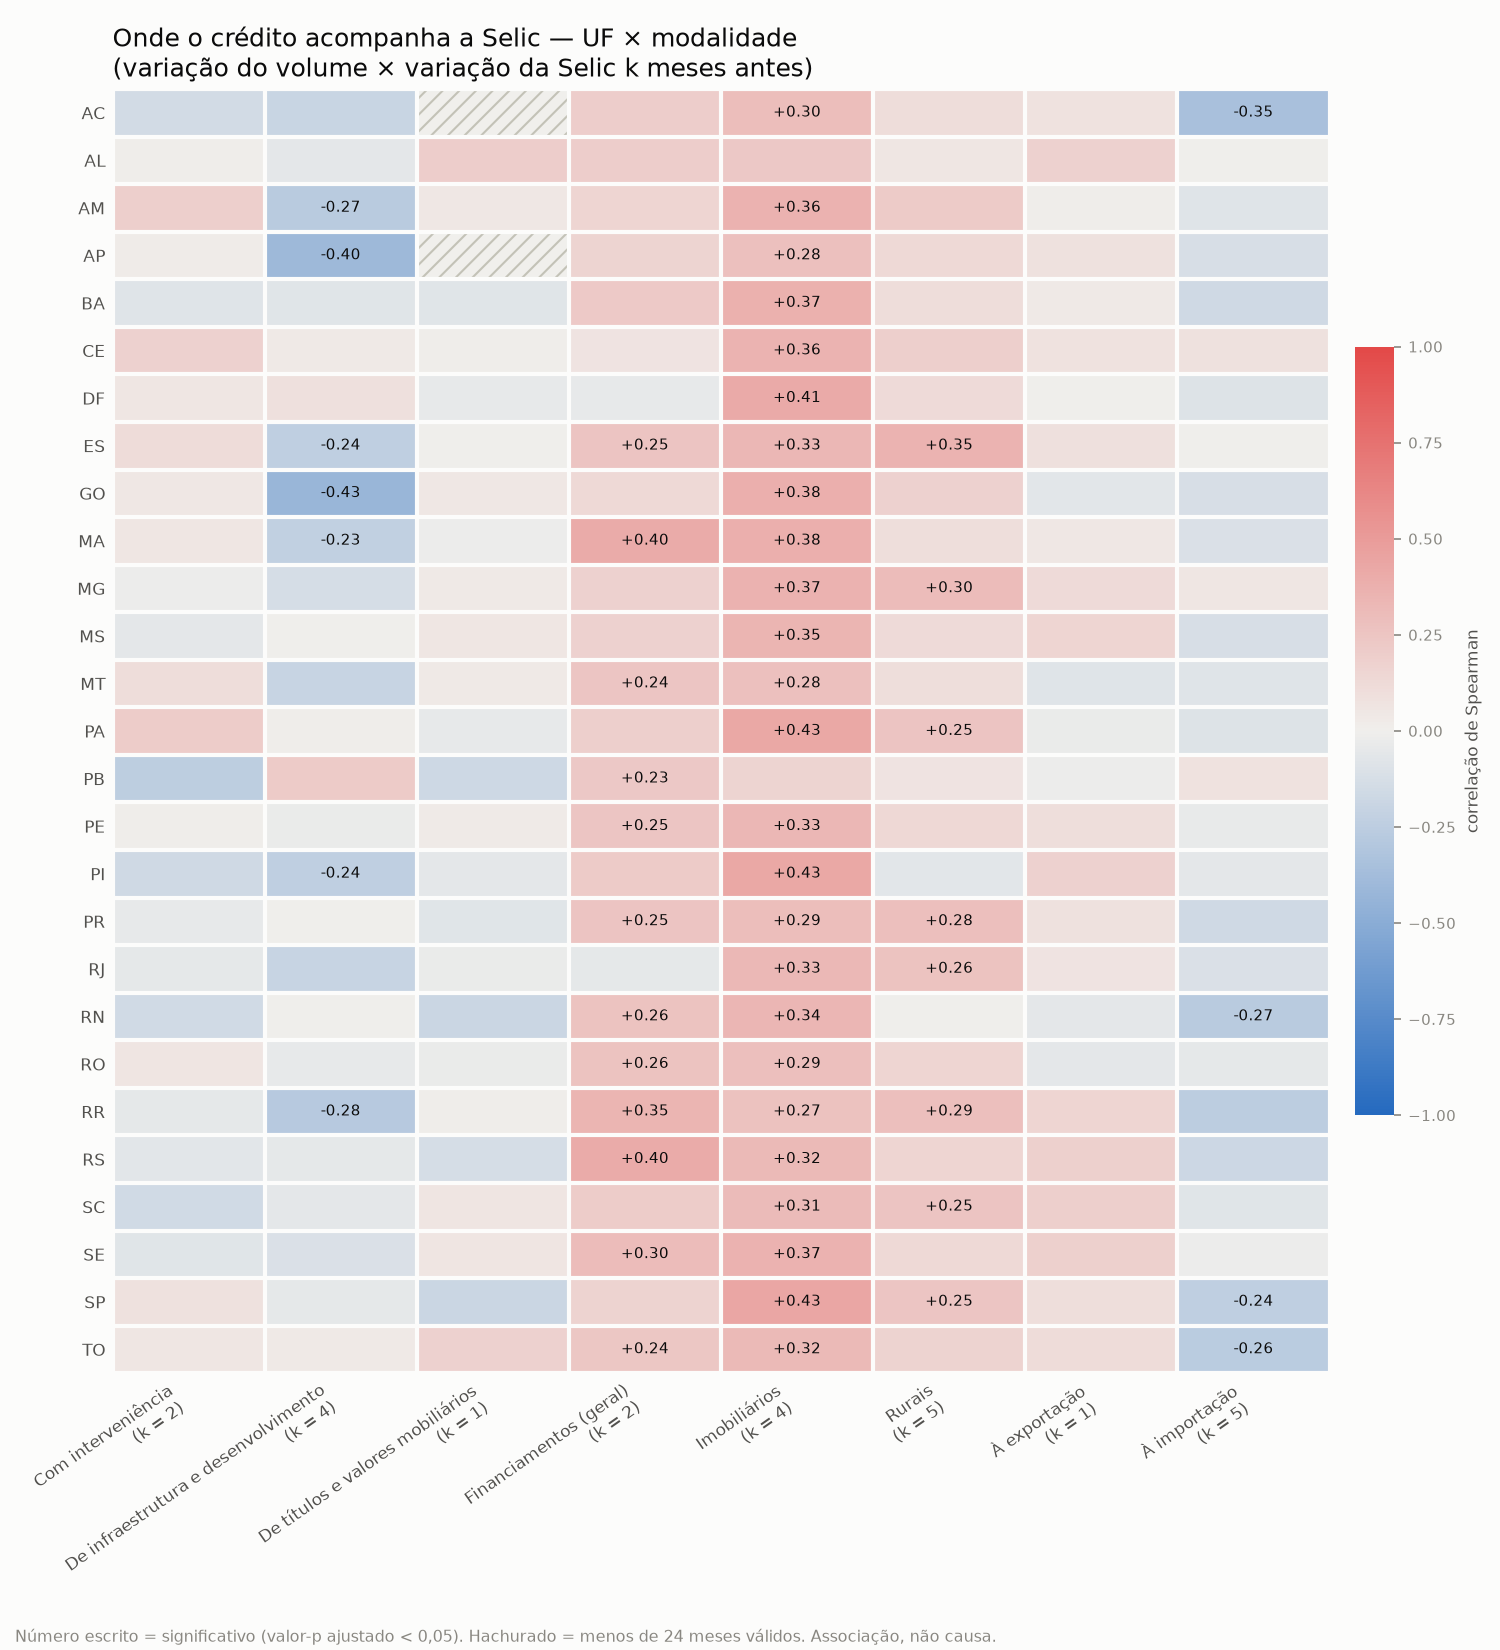

In [5]:
display(Image(filename=str(config.DIR_FIGURAS / "mapa_calor_uf_modalidade.png")))

In [6]:
calculadas = uf[~uf["amostra_insuficiente"]]
significativas = uf[uf["significativo"]].assign(modalidade=lambda d: d["modalidade"].map(nome_curto))
print(f"Combinações calculadas: {len(calculadas)} | amostra insuficiente: {uf['amostra_insuficiente'].sum()} | "
      f"significativas: {len(significativas)} ({(significativas['spearman'] > 0).sum()} positivas, "
      f"{(significativas['spearman'] < 0).sum()} negativas)")
significativas.groupby("modalidade").agg(combinacoes=("uf", "size"), spearman_mediano=("spearman", "median"),
                                         defasagem=("defasagem_meses", "first")).round(2)

Combinações calculadas: 214 | amostra insuficiente: 2 | significativas: 56 (45 positivas, 11 negativas)


,combinacoes,spearman_mediano,defasagem
modalidade,,,
De infraestrutura e desenvolvimento,7,-0.27,4
Financiamentos (geral),12,0.26,2
Imobiliários,25,0.34,4
Rurais,8,0.27,5
À importação,4,-0.27,5


## 4. Cuidados na leitura

- **Muitos testes.** São 56 correlações no nível Brasil e 214 no nível estadual. Com tantas, algumas dariam "significativas" por acaso; o valor-p foi **ajustado por Benjamini-Hochberg** e só conta como significativo o que tem valor-p ajustado < 0,05.
- **Associação, não causa.** Renda, emprego, safra e política de crédito dos bancos não são controlados (seção 11).
- **Quantidade de operações subestimada.** A análise usa o **volume** (saldo), que é completo; a quantidade tem 28% das linhas escondidas pelo BCB (limitação 9).
- **Saldo, não concessão.** A variação do saldo é o resultado de novos financiamentos menos pagamentos — não o que foi concedido no mês (limitação 1).
- **Valores nominais e sazonalidade não tratados.** Sem correção pela inflação e sem ajuste sazonal (limitações 3 e 11).
- **Muitos meses sem mudança da Selic.** A meta mudou em menos da metade dos meses; nos demais `var_selic_pp` = 0. É o retrato fiel da política, mas limita o quanto a análise consegue distinguir.